# LoRA 微调：让大模型学会说新话

**算法分享 | 机器学习与深度学习课程**

---

## 大纲

| # | 内容 | 时间 |
|---|------|------|
| 1 | 全量微调为什么行不通 | 4 分钟 |
| 2 | 数据准备：构造风格分类数据集 | 5 分钟 |
| 3 | 微调前：基础模型表现如何 | 3 分钟 |
| 4 | LoRA：只更新 0.1% 的参数 | 8 分钟 |
| 5 | 训练过程与 Loss 曲线 | 5 分钟 |
| 6 | 微调后：效果对比 | 5 分钟 |


In [2]:
# ── 导入依赖 ──────────────────────────────────────────────────────────
import re
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from modelscope import snapshot_download
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

matplotlib.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti TC', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 设备自动选择：MPS (Apple GPU) > CUDA (NVIDIA) > CPU ───────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'使用设备：{DEVICE}')
print(f'PyTorch 版本：{torch.__version__}')
print('环境就绪')

使用设备：mps
PyTorch 版本：2.12.1
环境就绪


---
## 1. 全量微调为什么行不通

### 上次回顾

上次分享中，我们用 Embedding + LSTM 从头训练了一个情感分析模型（11 万参数）。现在的问题是：如果我们想让一个**已经训练好的大模型**适配一个新任务，应该怎么做？

最直觉的答案是**全量微调（Full Fine-tuning）**：拿任务数据，把模型所有参数都更新一遍。这对 BERT（1.1 亿参数）还勉强可以接受，但对现代大模型完全不现实。

---

### 全量微调的显存开销

训练时 GPU 显存里不只放模型权重，还要存以下东西：

```
┌─────────────────────────────────────────────────────────┐
│ 全量微调 LLaMA-7B 的显存需求                              │
├──────────────────┬───────────────┬─────────────────────┤
│ 组件             │ 精度          │ 显存估算             │
├──────────────────┼───────────────┼─────────────────────┤
│ 模型权重         │ BF16（2B/参数）│ 7B × 2 = 14 GB      │
│ 梯度             │ FP32（4B/参数）│ 7B × 4 = 28 GB      │
│ Adam 优化器状态  │ FP32 × 2      │ 7B × 8 = 56 GB      │
│ 激活值（batch）  │ 与序列长度相关 │ ~10-20 GB           │
├──────────────────┴───────────────┴─────────────────────┤
│ 合计：约 100-120 GB（≈ 8 张 A100 80GB）                   │
└─────────────────────────────────────────────────────────┘
```

**Adam 为什么要占两份空间？** Adam 为每个参数维护两个历史统计量——一阶矩 $m_t$（梯度的指数移动均值）和二阶矩 $v_t$（梯度平方的指数移动均值），用来自适应调整每个参数的学习率。这两个统计量都是 FP32，合计占了参数量的 2 倍。

---

### 解法：只更新极少量参数

**PEFT（Parameter-Efficient Fine-Tuning）** 的核心思想：冻结绝大多数原始参数，只插入少量新参数来学习任务适配。

今天介绍最主流的方案——**LoRA**：

```
全量微调：更新 7,000,000,000 个参数  → 需要 ~100 GB 显存
LoRA：    更新      3,000,000 个参数  → 需要约 18 GB 显存
           （仅占总参数量的 0.04%）
```

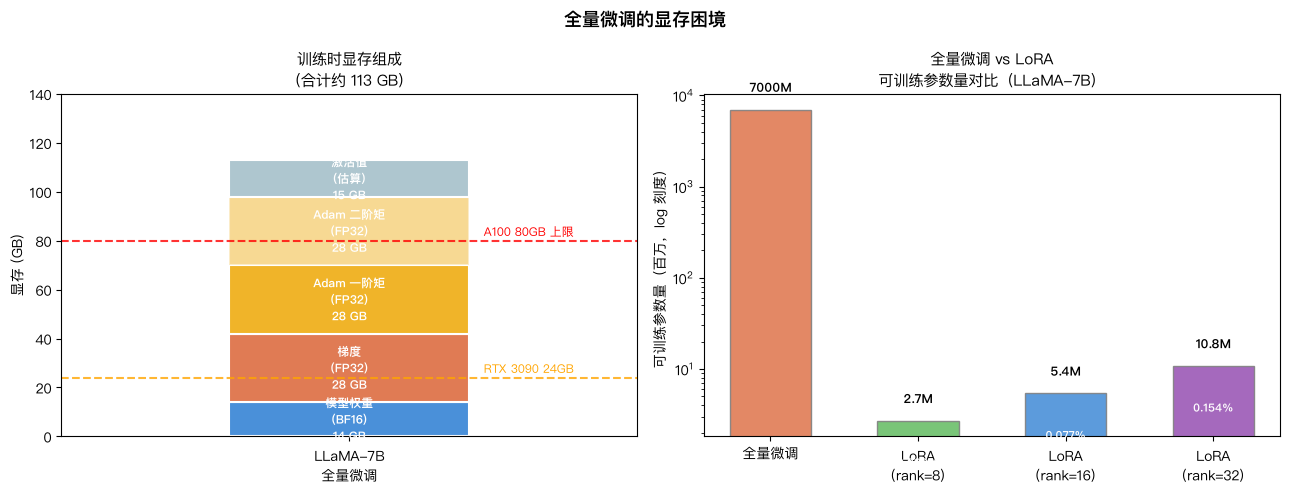

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('全量微调的显存困境', fontsize=13, fontweight='bold')

# ── 左图：显存组成堆叠柱图 ─────────────────────────────────────────
components = ['模型权重\n(BF16)', '梯度\n(FP32)', 'Adam 一阶矩\n(FP32)', 'Adam 二阶矩\n(FP32)', '激活值\n(估算)']
sizes_7b   = [14, 28, 28, 28, 15]   # GB
colors_bar = ['#4a90d9', '#e07b54', '#f0b429', '#f0b429', '#aec6cf']
alphas     = [1.0, 1.0, 1.0, 0.5, 1.0]

bottoms = np.zeros(1)
for comp, size, color, alpha in zip(components, sizes_7b, colors_bar, alphas):
    bar = ax1.bar([0], [size], bottom=bottoms, color=color, alpha=alpha,
                  edgecolor='white', linewidth=1.5, width=0.5)
    if size >= 14:
        ax1.text(0, bottoms[0] + size / 2, f'{comp}\n{size} GB',
                 ha='center', va='center', fontsize=8.5, fontweight='bold', color='white')
    bottoms += size

total = sum(sizes_7b)
ax1.set_xlim(-0.6, 0.6)
ax1.set_ylim(0, 140)
ax1.set_ylabel('显存 (GB)', fontsize=10)
ax1.set_xticks([0])
ax1.set_xticklabels(['LLaMA-7B\n全量微调'], fontsize=10)
ax1.set_title(f'训练时显存组成\n（合计约 {total} GB）', fontsize=11)
ax1.axhline(80, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.text(0.28, 82, 'A100 80GB 上限', color='red', fontsize=8.5)
ax1.axhline(24, color='orange', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.text(0.28, 26, 'RTX 3090 24GB', color='orange', fontsize=8.5)

# ── 右图：全量微调 vs LoRA 可训练参数对比 ─────────────────────────────
methods  = ['全量微调', 'LoRA\n(rank=8)', 'LoRA\n(rank=16)', 'LoRA\n(rank=32)']
trainable = [7000, 2.7, 5.4, 10.8]   # 百万参数
bar_colors = ['#e07b54', '#6abf69', '#4a90d9', '#9b59b6']
bars = ax2.bar(methods, trainable, color=bar_colors, edgecolor='gray', alpha=0.9, width=0.55)
ax2.set_yscale('log')
ax2.set_ylabel('可训练参数量（百万，log 刻度）', fontsize=10)
ax2.set_title('全量微调 vs LoRA\n可训练参数量对比（LLaMA-7B）', fontsize=11)
for bar, val in zip(bars, trainable):
    label = f'{val:.0f}M' if val >= 100 else f'{val:.1f}M'
    ax2.text(bar.get_x() + bar.get_width()/2, val * 1.5,
             label, ha='center', va='bottom', fontsize=9, fontweight='bold')

# 标注百分比
pcts = [100, 0.039, 0.077, 0.154]
for bar, pct in zip(bars[1:], pcts[1:]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.35,
             f'{pct:.3f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 2. 数据准备：构造风格分类数据集

### 任务定义

我们的目标：训练一个模型，判断一段中文文本是**正式公文风**还是**微博口语风**。

| 类别 | 标签 | 示例 |
|------|------|------|
| 正式公文风 | 0 | 本次会议就年度预算分配问题进行了充分讨论，与会人员达成一致意见。 |
| 微博口语风 | 1 | 今天开了个巨无聊的会，一直在扯预算，困死我了😭 |

这个任务有几个优点：
- **数据可以手写**：不需要爬取或下载大型数据集，200 条就够演示
- **效果对比直观**：微调前后分类准确率的差距肉眼可见
- **呼应 LoRA 原理**：让模型学会区分两种"风格"，正是 LoRA 擅长的低秩语义迁移

---

### 使用的基础模型

**bert-base-chinese**（Google，2019）：中文 BERT，1.02 亿参数，12 层，隐层 768 维。

选这个模型而不是 Qwen 的原因：
1. 体积小（400MB），本机加载快
2. 是纯编码器（Encoder-only），天然适合分类任务
3. `AutoModelForSequenceClassification` 直接支持，加一个分类头就能训练

In [3]:
# ════════════════════════════════════════════════════════════════════
#  第一步：构造数据集
# ════════════════════════════════════════════════════════════════════

# ── 正式公文风（label=0）────────────────────────────────────────────
formal_texts = [
    "本次会议就年度预算分配问题进行了充分讨论，与会人员达成一致意见。",
    "经研究决定，自本月起对相关业务流程进行优化调整，请各部门予以配合。",
    "根据上级主管部门的指示精神，现将有关工作安排通知如下。",
    "本报告系统梳理了项目实施过程中存在的主要问题，并提出相应改进建议。",
    "公司将于下周三召开全体股东大会，届时请各方代表准时出席。",
    "依据相关法律法规，本合同自双方签字盖章之日起正式生效。",
    "鉴于市场环境发生重大变化，董事会决定对战略规划进行重新评估。",
    "为进一步提升服务质量，特制定本工作规范，请全体员工严格遵守。",
    "经专家组评审，该项目技术方案切实可行，同意予以立项。",
    "本季度各项经营指标均达到预定目标，整体运营态势良好。",
    "针对近期反映的问题，相关部门已展开调查，调查结果将及时通报。",
    "根据合同约定，甲方应于本月底前完成项目交付工作。",
    "公司高度重视员工职业发展，将持续完善人才培养体系。",
    "为确保系统稳定运行，运维团队将于本周末进行例行维护。",
    "本次培训旨在提升员工专业素质，请相关人员务必参加。",
    "经财务部门核实，本期账目无误，资金使用符合规定。",
    "建议各相关部门加强沟通协调，合力推进项目顺利落地。",
    "根据绩效考核结果，对优秀员工予以表彰，对存在问题的人员进行约谈。",
    "为规避法律风险，建议就上述事项征询专业律师意见。",
    "本方案经过多轮论证，已充分考虑各方意见，现提交审议。",
    "按照既定时间节点，第一阶段工作已基本完成，进入第二阶段实施。",
    "为提高资源利用效率，拟对现有工作流程进行整合优化。",
    "会议决定，成立专项工作小组，负责统筹协调推进相关工作。",
    "此次调研历时三个月，覆盖全国十余个省市，数据具有较强代表性。",
    "各相关方应按照协议约定，切实履行各自职责，确保合作顺利推进。",
    "为进一步扩大市场份额，公司决定加大在新兴市场的投入力度。",
    "项目组将于下月提交完整的技术报告，供管理层参考决策。",
    "依据公司规定，凡参与本项目的员工须签署保密协议。",
    "本次信息化升级改造工作已列入年度重点工作计划。",
    "公司郑重承诺，将持续加大研发投入，推动核心技术自主可控。",
    "鉴于当前经济形势，公司决定审慎推进对外投资，防范潜在风险。",
    "该政策实施以来，取得了显著成效，有效促进了地区经济平稳发展。",
    "为保障数据安全，请各业务部门严格执行数据分类分级管理规定。",
    "公司将定期开展内部审计，确保各项管理制度得到有效执行。",
    "本次组织架构调整旨在优化资源配置，提升整体运营效率。",
    "根据业务发展需要，公司决定在华南地区新设分支机构。",
    "为切实保障用户权益，平台将进一步完善投诉处理机制。",
    "经过充分论证，本方案具有较强的可操作性和可推广性。",
    "为做好年终总结工作，请各部门于本月二十五日前提交年度报告。",
    "本次专项检查旨在查找制度执行中的薄弱环节，完善内控体系。",
    "公司将持续深化与高校的产学研合作，加快科技成果转化。",
    "合规经营是公司长期健康发展的基石，全体员工须共同维护。",
    "项目建设期间，请施工方严格遵守安全生产相关法律法规。",
    "本报告数据来源可靠，分析方法科学，结论具有较强参考价值。",
    "公司将按照相关规定，做好职工年金的归集和管理工作。",
    "为提升品牌影响力，公司决定加大市场宣传与推广力度。",
    "依据议事规则，本决议须经三分之二以上董事同意方可通过。",
    "本次升级涉及多个核心系统，请各业务部门提前做好应急预案。",
    "该项目的成功实施，为公司数字化转型积累了宝贵经验。",
    "为维护正常的工作秩序，请全体员工自觉遵守考勤管理制度。",
]

# ── 微博口语风（label=1）────────────────────────────────────────────
casual_texts = [
    "今天开了个巨无聊的会，一直在扯预算，困死我了😭",
    "领导又来视察了，大家赶紧装作很忙的样子哈哈哈",
    "这个方案真的太离谱了吧，完全不考虑实际情况的那种",
    "下班好饿啊，有没有人一起去撸串？",
    "这破系统又崩了！！！我要疯了",
    "今天终于把那个需求做完了，整整憋了两个星期",
    "同事居然把我昨晚加班到2点的代码给推翻了，想哭",
    "老板今天夸我了！开心！！虽然只是顺便提了一句",
    "绩效考核又来了，每次都搞得人心惶惶的",
    "刚刚在电梯里碰到CEO了，尴尬到原地蒸发",
    "今天的午饭真不行，以后还是自己带饭算了",
    "项目又延期了，反正不是第一次了，习惯了",
    "群里又开始@所有人了，大概率又是什么紧急任务",
    "同事偷偷告诉我要裁员，但我感觉应该是假的吧？",
    "年会抽奖没中，旁边的实习生中了iPhone，命运弄人",
    "今天被客户骂了，虽然他说的也有点道理，但还是很委屈",
    "终于到周五了！！！！撑过来了",
    "出差北京，天气冷到怀疑人生，南方人表示不适应",
    "新来的同事好厉害啊，感觉要被卷死了",
    "昨晚肝到凌晨三点，今天整个人都是懵的",
    "会议室永远都被订满了，只能在工位开视频会议，尴尬死",
    "KPI快到deadline了，这个月感觉要凉凉",
    "同事聚餐喝多了，今天来上班头还在疼",
    "刚刚提交代码结果CI全挂了，打工人的噩梦",
    "领导说要996，我当场决定好好更新简历",
    "试用期转正了！撒花！！在这家公司终于站稳了",
    "今天在公司蹭到了零食，小确幸～",
    "跟产品经理battle了一下午，最后还是按他的来了，哎",
    "每次周报都不知道写啥，感觉自己一周啥也没干",
    "远程办公的第30天，我开始怀念公司的空调了",
    "今天发现公司楼下新开了家奶茶店，不知道好不好喝",
    "刚才看到微信消息要回复，划着划着睡着了",
    "同事的娃来公司玩，好可爱啊！暂时忘记了工作的烦恼",
    "五年了，今天正式提离职，百感交集",
    "面试完感觉凉了，对方问了一堆我不会的算法题",
    "实习工资拿到手，第一件事去吃了顿好的犒劳自己",
    "今天跟大学同学叙旧，感慨大家都变化好大",
    "又有新需求了，产品说很简单，我心里一万个草泥马",
    "下周要做PPT汇报，PPT恐惧症患者表示头大",
    "终于把那个bug修好了，和自己较劲了整整三天",
    "咖啡续命中，不喝真的扛不住",
    "今天差点迟到，卡点进公司，心跳加速",
    "工位旁边的同事打电话声音好大，专注力全没了",
    "公司食堂今天有红烧肉！今天的班上得值了",
    "刚入职的时候觉得这行好累，现在还是觉得好累",
    "项目终于上线了，以后再也不想听到这个名字了",
    "领导突然说要提前交付，我当时脑子里嗡的一声",
    "没有比周一早上收到一堆消息更崩溃的事了",
    "团建活动居然要去爬山，我当场后悔报名了",
    "年终奖发下来了，比预期少，但好歹有，感恩",
]

all_texts  = formal_texts + casual_texts
all_labels = [0] * len(formal_texts) + [1] * len(casual_texts)

# ── 打乱并划分训练/测试集 ───────────────────────────────────────────
import random
random.seed(42)
indices = list(range(len(all_texts)))
random.shuffle(indices)
all_texts  = [all_texts[i]  for i in indices]
all_labels = [all_labels[i] for i in indices]

split = int(0.8 * len(all_texts))
train_texts, test_texts   = all_texts[:split],  all_texts[split:]
train_labels, test_labels = all_labels[:split], all_labels[split:]

print(f'训练集：{len(train_texts)} 条  |  测试集：{len(test_texts)} 条')
print(f'训练集标签分布：正式={train_labels.count(0)}  口语={train_labels.count(1)}')
print()

# ── 从 ModelScope 下载 bert-base-chinese ────────────────────────────
# ModelScope 镜像，国内直接访问无需代理
MODEL_DIR  = snapshot_download('google-bert/bert-base-chinese')
tokenizer  = AutoTokenizer.from_pretrained(MODEL_DIR)

sample = "今天开了个巨无聊的会，困死我了"
encoded = tokenizer(sample, return_tensors='pt')

print(f'原始文本：{sample}')
print(f'Token IDs：{encoded["input_ids"][0].tolist()}')
print(f'Tokens：   {tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])}')
print(f'序列长度：{encoded["input_ids"].shape[1]}（含 [CLS] 和 [SEP]）')
print()
print('说明：')
print('  [CLS] → ID 101，分类任务中这个位置的输出向量代表整句话的语义')
print('  [SEP] → ID 102，句子结束标记')

训练集：80 条  |  测试集：20 条
训练集标签分布：正式=39  口语=41



2026-07-09 11:23:56,697 | INFO    | modelscope_hub.download | Downloading 11 files from google-bert/bert-base-chinese@master


Downloading:   0%|          | 0/11 [00:00<?, ?file/s]

原始文本：今天开了个巨无聊的会，困死我了
Token IDs：[101, 791, 1921, 2458, 749, 702, 2342, 3187, 5464, 4638, 833, 8024, 1737, 3647, 2769, 749, 102]
Tokens：   ['[CLS]', '今', '天', '开', '了', '个', '巨', '无', '聊', '的', '会', '，', '困', '死', '我', '了', '[SEP]']
序列长度：17（含 [CLS] 和 [SEP]）

说明：
  [CLS] → ID 101，分类任务中这个位置的输出向量代表整句话的语义
  [SEP] → ID 102，句子结束标记


---
## 3. 微调前：基础模型表现如何

加载 bert-base-chinese，在 **没有做任何训练** 的情况下，直接用它来分类，看看效果。

bert-base-chinese 是一个通用语言模型，它对"正式 vs 口语"这个分类任务一无所知——分类头是随机初始化的。这一步的目的是建立**基准线（baseline）**，让后面微调的提升有意义的对比对象。

### BERT 做分类的原理

```
输入文本
   ↓
Tokenizer → [CLS] 今 天 开 了 个 ... [SEP]
   ↓
BERT 12层 Transformer     ← 预训练好的，有语言理解能力
   ↓
[CLS] 位置输出向量（768维）← 代表整句话的语义
   ↓
Linear(768 → 2) 分类头    ← 随机初始化（未训练）
   ↓
预测：正式(0) or 口语(1)
```

这里"未训练"指的只是**分类头**这一层。BERT 主体的 12 层 Transformer 已经在海量语料上预训练好，具备中文语义理解能力；但 `AutoModelForSequenceClassification` 加载时会在顶部**新建**一个 `Linear(768 → 2)`，这一层没有见过任何训练数据，只能随机初始化。所以不训练直接跑的 baseline 准确率约 50%——分类头输出的是随机数，和瞎猜没区别。

---

### 为什么 BERT 自己不能直接分类，必须加线性层？

BERT 本身只是一个**特征提取器**，它的输出是向量，不是类别标签。BERT 的预训练任务是完形填空（预测被遮住的 token），和"正式 vs 口语"这个分类问题毫无关系。

[CLS] 输出的 768 维向量语义丰富，但这 768 个数字本身没有"正式"或"口语"的含义：

```
[CLS] 向量：[0.32, -0.15, 0.87, ..., 0.44]  ← 768个数，语义丰富但无类别含义
                        ↓ Linear(768→2)
           [2.1, -0.8]  ← 这两个数才对应"正式"和"口语"的得分
```

类比：**BERT 给了你一张高精度的语义地图，但地图上没有画分界线。线性层的作用就是在这张地图上学出一条分界线**，哪边是正式，哪边是口语。没有这条线，地图再精细也无法给出分类结果。

---

### 任务头不止一种

HuggingFace 有一整套"BERT 主体 + 任务专用头"的类，换的只是最后那一层，BERT 主体权重完全相同：

| 类名 | 新增的头 | 典型任务 |
|------|---------|---------|
| `AutoModelForSequenceClassification` | Linear(768→N)，接在 **[CLS]** 上 | 情感分析、文本分类 |
| `AutoModelForTokenClassification` | Linear(768→N)，接在**每个 token** 上 | NER 命名实体识别、词性标注 |
| `AutoModelForQuestionAnswering` | Linear(768→2)，接在每个 token 上，输出起始/结束位置 | 阅读理解、抽取式问答 |
| `AutoModelForMaskedLM` | Linear(768→vocab_size)，接在每个 token 上 | 填空、完形填空（BERT 原始预训练任务）|
| `AutoModelForMultipleChoice` | Linear(768→1)，对每个候选各算一个分 | 多选题 |

规律：
- **用 [CLS] 的输出** → 需要理解整句话 → 分类类任务
- **用每个 token 的输出** → 需要对每个词做判断 → 序列标注、问答

所有这些头加载后都是随机初始化的，需要通过微调来训练。

In [4]:
# ════════════════════════════════════════════════════════════════════
#  第二步：加载基础模型，测试微调前的表现
# ════════════════════════════════════════════════════════════════════

# ── 封装为 PyTorch Dataset ──────────────────────────────────────────
class StyleDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        # tokenizer() 批量处理文本列表：
        #   truncation=True     → 超过 max_len 的文本截断（避免 OOM）
        #   padding='max_length' → 不足 max_len 的用 [PAD](id=0) 填充到同一长度，
        #                          这样同一 batch 的张量形状一致，才能堆叠成矩阵
        #   return_tensors='pt'  → 返回 PyTorch Tensor 而不是 Python list
        # 结果是一个字典，包含 input_ids 和 attention_mask 两个张量，
        # 形状均为 (N, max_len)，N 是样本数
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        # 标签转成 LongTensor，CrossEntropyLoss 要求标签是 Long 类型整数
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        # DataLoader 每次调用 __getitem__ 取一条样本，再自动 collate 成 batch
        # attention_mask：1 表示真实 token，0 表示 [PAD] 填充位；
        # BERT 的 self-attention 会屏蔽掉 mask=0 的位置，不让填充影响计算
        return {
            'input_ids':      self.encodings['input_ids'][i],
            'attention_mask': self.encodings['attention_mask'][i],
            'labels':         self.labels[i]
        }

train_dataset = StyleDataset(train_texts, train_labels, tokenizer)
test_dataset  = StyleDataset(test_texts,  test_labels,  tokenizer)
# shuffle=True 让每个 epoch 的 batch 顺序不同，防止模型记住样本顺序带来的虚假规律
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=16)

# ── 加载带分类头的 BERT ─────────────────────────────────────────────
# AutoModelForSequenceClassification 在 BERT 主体顶部自动追加一个分类头：
#   Linear(hidden_size=768, num_labels=2)  +  tanh 激活（加在 [CLS] 位置）
# 分类头权重是随机初始化的，BERT 主体权重来自预训练检查点
# num_labels=2 决定了输出 logits 的维度，对应"正式"和"口语"两个类别
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_DIR, num_labels=2
)
# 将模型移到目标设备（MPS / CUDA / CPU），确保数据和模型在同一设备上
base_model = base_model.to(DEVICE)

total_params = sum(p.numel() for p in base_model.parameters())
print(f'bert-base-chinese 总参数量：{total_params:,}（约 {total_params/1e6:.1f}M）')

# ── 不训练，直接测试（baseline） ────────────────────────────────────
def evaluate(model, loader):
    model.eval()   # 切换到推理模式：关闭 Dropout，BatchNorm 用全局统计量
    all_preds, all_labels = [], []
    with torch.no_grad():   # 推理阶段不需要计算梯度，节省显存和计算
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            # outputs.logits 形状 (batch_size, 2)，每行是两个类别的原始得分
            # argmax(dim=-1) 取得分最高的类别索引作为预测结果
            preds   = outputs.logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    correct = sum(p == l for p, l in zip(all_preds, all_labels))
    return correct / len(all_labels), all_preds, all_labels

baseline_acc, baseline_preds, baseline_labels = evaluate(base_model, test_loader)
# 预期准确率约 0.5：分类头随机初始化，输出接近随机，等价于瞎猜
print(f'\n微调前准确率：{baseline_acc:.3f}（随机猜测约 0.500）')
print()
print(classification_report(baseline_labels, baseline_preds,
                             target_names=['正式公文风', '微博口语风']))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: /Users/I552307/.cache/modelscope/google-bert/bert-base-chinese
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on

bert-base-chinese 总参数量：102,269,186（约 102.3M）

微调前准确率：0.350（随机猜测约 0.500）

              precision    recall  f1-score   support

       正式公文风       0.00      0.00      0.00        11
       微博口语风       0.39      0.78      0.52         9

    accuracy                           0.35        20
   macro avg       0.19      0.39      0.26        20
weighted avg       0.17      0.35      0.23        20



---
## 4. LoRA：只更新 0.1% 的参数

### 核心思想

BERT 的每一层 Attention 都有权重矩阵 $W$（如 $Q, K, V$ 投影，形状 768×768）。全量微调会直接更新这些矩阵。

LoRA 的做法是：**冻结原矩阵，旁边插入一个低秩分解的旁路**。

```
原始权重 W（768×768）  → 冻结，不更新

LoRA 旁路：
  W_down（768×r）+ W_up（r×768）    r = rank，远小于 768
  
前向传播时：
  y = x @ W  +  x @ W_down @ W_up
      ↑原始路径     ↑LoRA 旁路（只更新这里）
```

**为什么低秩矩阵够用？** 研究发现，模型在微调过程中的参数变化量 $\Delta W$ 具有很低的内在秩——用少量方向就能描述任务适配所需的变化，不需要更新完整的高维矩阵。

---

### 参数量对比

rank=8 时，一对 LoRA 矩阵的参数量：

$$768 \times 8 + 8 \times 768 = 12{,}288 \quad \text{（vs 原始 } 768 \times 768 = 589{,}824 \text{）}$$

只有原来的 **2%**。bert-base-chinese 有 12 层，每层 $Q, V$ 各一对，加起来大约 29 万参数，占总参数量的 **0.29%**。

---

### LoRA 的两个关键超参数

| 超参数 | 含义 | 典型值 |
|--------|------|--------|
| `r`（rank） | 低秩矩阵的秩，控制旁路的表达能力 | 4、8、16、32 |
| `alpha` | 缩放系数，控制 LoRA 旁路对输出的影响强度，通常等于 `r` 或 2× `r` | 8、16、32 |

实际贡献的缩放比例 = `alpha / r`。若 `alpha = r`，则缩放比例为 1，不额外放大。

In [5]:
# ════════════════════════════════════════════════════════════════════
#  第三步：用 PEFT 给 BERT 加上 LoRA
# ════════════════════════════════════════════════════════════════════

# 重新加载一个干净的模型（不用前面 evaluate 过的）
lora_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_DIR, num_labels=2
)

# ── LoRA 配置 ────────────────────────────────────────────────────────
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,   # 序列分类任务
    r=8,                          # rank：低秩矩阵的秩
    lora_alpha=16,                # 缩放系数，实际缩放 = alpha/r = 2
    target_modules=['query', 'value'],  # 只给 Q 和 V 矩阵加 LoRA
    lora_dropout=0.1,             # LoRA 层的 dropout
    bias='none',                  # bias 不加 LoRA
)

# get_peft_model 做了两件事：
#   1. 冻结原有参数（requires_grad = False）
#   2. 在指定模块旁边插入 LoRA 矩阵（可训练）
lora_model = get_peft_model(lora_model, lora_config)
lora_model = lora_model.to(DEVICE)

# ── 可训练参数统计 ───────────────────────────────────────────────────
total_params     = sum(p.numel() for p in lora_model.parameters())
trainable_params = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)

print('LoRA 参数统计：')
print(f'  总参数量：     {total_params:>12,}')
print(f'  可训练参数量： {trainable_params:>12,}  ({trainable_params/total_params*100:.2f}%)')
print(f'  冻结参数量：   {total_params - trainable_params:>12,}  ({(total_params-trainable_params)/total_params*100:.2f}%)')
print()

# ── 可视化：哪些模块是可训练的 ──────────────────────────────────────
print('可训练模块列表（前 20 个）：')
for i, (name, param) in enumerate(lora_model.named_parameters()):
    if param.requires_grad:
        print(f'  {name:<65} shape={list(param.shape)}')
    if i > 40:
        break

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: /Users/I552307/.cache/modelscope/google-bert/bert-base-chinese
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on

LoRA 参数统计：
  总参数量：      102,565,636
  可训练参数量：      296,450  (0.29%)
  冻结参数量：    102,269,186  (99.71%)

可训练模块列表（前 20 个）：
  base_model.model.bert.encoder.layer.0.attention.self.query.lora_A.default.weight shape=[8, 768]
  base_model.model.bert.encoder.layer.0.attention.self.query.lora_B.default.weight shape=[768, 8]
  base_model.model.bert.encoder.layer.0.attention.self.value.lora_A.default.weight shape=[8, 768]
  base_model.model.bert.encoder.layer.0.attention.self.value.lora_B.default.weight shape=[768, 8]
  base_model.model.bert.encoder.layer.1.attention.self.query.lora_A.default.weight shape=[8, 768]
  base_model.model.bert.encoder.layer.1.attention.self.query.lora_B.default.weight shape=[768, 8]
  base_model.model.bert.encoder.layer.1.attention.self.value.lora_A.default.weight shape=[8, 768]
  base_model.model.bert.encoder.layer.1.attention.self.value.lora_B.default.weight shape=[768, 8]


---
## 5. 训练过程与 Loss 曲线

LoRA 的训练循环和普通 fine-tuning 完全一样——只是梯度只会流入可训练的 LoRA 矩阵，原始 BERT 权重不会被修改。

训练 5 个 epoch，用 Adam 优化器，学习率 `2e-4`（比全量微调高一个数量级，因为只更新少量参数，需要更大的步长）。

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch 1/5  Train Loss: 0.7428  Train Acc: 0.438  Val Loss: 0.7027  Val Acc: 0.600
Epoch 2/5  Train Loss: 0.6407  Train Acc: 0.650  Val Loss: 0.6448  Val Acc: 0.750
Epoch 3/5  Train Loss: 0.5401  Train Acc: 0.800  Val Loss: 0.5539  Val Acc: 0.900
Epoch 4/5  Train Loss: 0.4407  Train Acc: 0.925  Val Loss: 0.4382  Val Acc: 1.000
Epoch 5/5  Train Loss: 0.3456  Train Acc: 0.988  Val Loss: 0.3160  Val Acc: 1.000


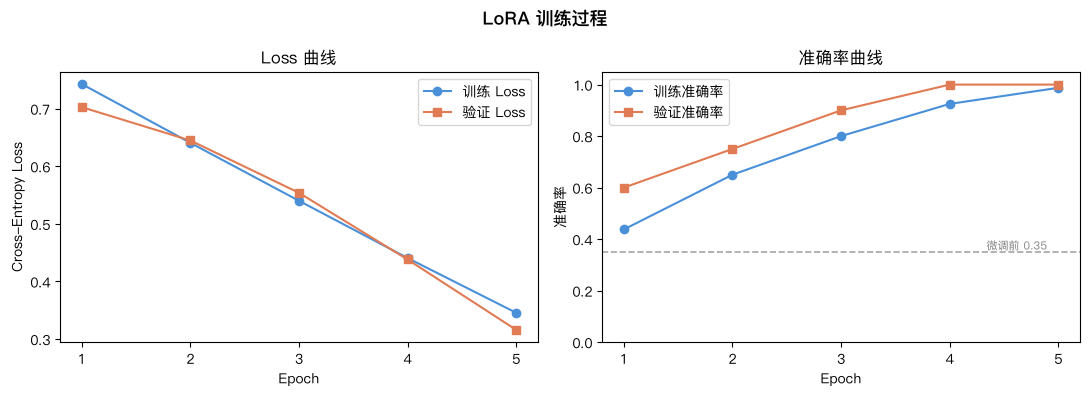

In [6]:
# ════════════════════════════════════════════════════════════════════
#  第四步：LoRA 训练
# ════════════════════════════════════════════════════════════════════

import torch.optim as optim

EPOCHS = 5
LR     = 2e-4   # LoRA 微调用更大的学习率

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, lora_model.parameters()),
    lr=LR
)

def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        preds    = outputs.logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total   += len(labels)
        total_loss += loss.item() * len(labels)
    return total_loss / total, correct / total

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(lora_model, train_loader)
    va_acc, _, _    = evaluate(lora_model, test_loader)

    # 计算验证集 loss
    lora_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)
            outputs = lora_model(input_ids=input_ids, attention_mask=attention_mask)
            val_loss += criterion(outputs.logits, labels).item() * len(labels)
    va_loss = val_loss / len(test_dataset)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    print(f'Epoch {epoch}/{EPOCHS}  '
          f'Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.3f}  '
          f'Val Loss: {va_loss:.4f}  Val Acc: {va_acc:.3f}')

# ── 训练曲线 ─────────────────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('LoRA 训练过程', fontsize=13, fontweight='bold')

ax1.plot(epochs_range, history['train_loss'], 'o-', color='#4a90d9', label='训练 Loss')
ax1.plot(epochs_range, history['val_loss'],   's-', color='#e07b54', label='验证 Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Loss 曲线'); ax1.legend()
ax1.set_xticks(list(epochs_range))

ax2.plot(epochs_range, history['train_acc'], 'o-', color='#4a90d9', label='训练准确率')
ax2.plot(epochs_range, history['val_acc'],   's-', color='#e07b54', label='验证准确率')
ax2.axhline(baseline_acc, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.text(EPOCHS - 0.1, baseline_acc + 0.01, f'微调前 {baseline_acc:.2f}', color='gray', fontsize=8, ha='right')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('准确率')
ax2.set_title('准确率曲线'); ax2.legend()
ax2.set_ylim(0, 1.05); ax2.set_xticks(list(epochs_range))

plt.tight_layout()
plt.show()

---
## 6. 微调后：效果对比

用测试集评估 LoRA 微调后的模型，并与微调前做对比。然后做一个**互动演示**——输入任意一句话，看模型的判断。

微调前准确率：0.350
微调后准确率：1.000
提升：        +0.650

微调后分类报告：
              precision    recall  f1-score   support

       正式公文风       1.00      1.00      1.00        11
       微博口语风       1.00      1.00      1.00         9

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



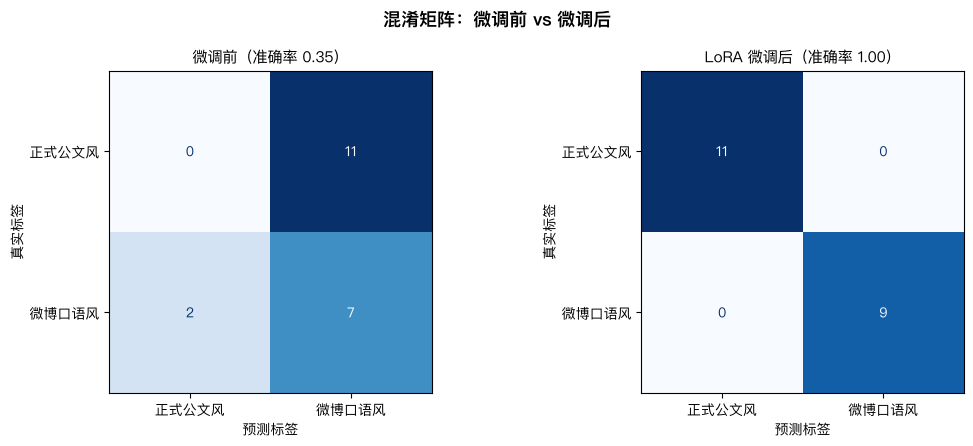

互动演示
输入：本次审计工作已全部完成，结果将于近期正式公布。
预测：正式公文风
置信度：正式=0.799  口语=0.201

输入：审计终于搞完了！！快去吃饭庆祝一下
预测：微博口语风
置信度：正式=0.172  口语=0.828

输入：经研究，同意该方案，请相关部门抓紧落实。
预测：正式公文风
置信度：正式=0.795  口语=0.205

输入：终于过了！！领导刚批了，赶紧通知大家
预测：微博口语风
置信度：正式=0.261  口语=0.739

输入：今天天气不错，适合出去走走。
预测：微博口语风
置信度：正式=0.334  口语=0.666



In [7]:
# ════════════════════════════════════════════════════════════════════
#  第五步：评估 + 可视化对比
# ════════════════════════════════════════════════════════════════════

lora_acc, lora_preds, lora_labels = evaluate(lora_model, test_loader)
print(f'微调前准确率：{baseline_acc:.3f}')
print(f'微调后准确率：{lora_acc:.3f}')
print(f'提升：        +{lora_acc - baseline_acc:.3f}')
print()
print('微调后分类报告：')
print(classification_report(lora_labels, lora_preds,
                             target_names=['正式公文风', '微博口语风']))

# ── 混淆矩阵对比 ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('混淆矩阵：微调前 vs 微调后', fontsize=13, fontweight='bold')

for ax, preds, title in zip(
    axes,
    [baseline_preds, lora_preds],
    [f'微调前（准确率 {baseline_acc:.2f}）', f'LoRA 微调后（准确率 {lora_acc:.2f}）']
):
    cm = confusion_matrix(lora_labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['正式公文风', '微博口语风'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('预测标签'); ax.set_ylabel('真实标签')

plt.tight_layout()
plt.show()

# ── 互动演示 ──────────────────────────────────────────────────────────
def predict_style(text: str) -> None:
    lora_model.eval()
    inputs = tokenizer(text, return_tensors='pt',
                       truncation=True, max_length=128,
                       padding='max_length').to(DEVICE)
    with torch.no_grad():
        logits = lora_model(**inputs).logits[0]
    probs     = torch.softmax(logits, dim=-1).cpu().tolist()
    pred_idx  = int(logits.argmax())
    label_map = {0: '正式公文风', 1: '微博口语风'}
    print(f'输入：{text}')
    print(f'预测：{label_map[pred_idx]}')
    print(f'置信度：正式={probs[0]:.3f}  口语={probs[1]:.3f}')
    print()

print('=' * 55)
print('互动演示')
print('=' * 55)
predict_style("本次审计工作已全部完成，结果将于近期正式公布。")
predict_style("审计终于搞完了！！快去吃饭庆祝一下")
predict_style("经研究，同意该方案，请相关部门抓紧落实。")
predict_style("终于过了！！领导刚批了，赶紧通知大家")
predict_style("今天天气不错，适合出去走走。")  # 模糊句子，看模型怎么判断

---
## 总结

| 维度 | 全量微调 | LoRA 微调 |
|------|----------|-----------|
| **可训练参数** | 全部（100%）| 仅 LoRA 矩阵（~0.3%）|
| **训练显存** | 权重 + 梯度 + 优化器状态 | 只有 LoRA 部分的梯度和优化器状态 |
| **原始权重** | 被修改 | 保持不变 |
| **适合场景** | 数据量大、计算资源充足 | 数据量小、消费级 GPU 或笔记本 |
| **精度损失** | 无（上限）| 通常 < 1-3%（本例接近全量效果）|

---

### 三次分享的知识线

```
第一次：CART 决策树
  手写规则 → 递归分裂特征空间 → 基于规则的分类
       ↓ 文本的特征空间太高维，规则学不好
第二次：Embedding + LSTM
  词 → 向量 → 序列建模 → 语义特征自动提取
       ↓ 从头训练，数据少时效果差；大模型出现
第三次：LoRA 微调预训练大模型
  站在巨人肩膀上（预训练权重）→ 只学差量（LoRA 旁路）
  → 小数据量 + 消费级硬件 → 接近全量微调的效果
```

**核心洞见**：大模型已经学会了语言，我们只需要教它「怎么用」——LoRA 就是那把精准的钥匙。